# Reprojection of FDM/RACMO grid over Greenland 

Here we show you how to transform the FDM/RACMO custom rotated pole to get geotiff projected files (or just reproject to a different CRS and write out to a netcdf)


following Stef Lehrmite at https://gitlab.tudelft.nl/slhermitte/manuals/blob/master/RACMO_reproject.md but updated to show both tools useable in a python environment (like xarray and rioxarray and osgeo's gdal python wrapper), as well as to generate the gdal commands you'd have to produce to use gdal in the terminal.



In [17]:
import xarray as xr
import rioxarray as rio
from pyproj import CRS
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
import rasterio.plot
import re
from osgeo import gdal

First we load the example file and see what's inside it. The post-processing of the FDM data uses the same rlat/rlon coordinates as the custom RACMO roatated pole projection. 

In [18]:
var = "FirnAir"

target_crs = "EPSG:3413"   # or e.g. "EPSG:4326"
target_crs_name = "EPSG3413" # colon causes problems in naming 

# To make all the examples run faster, limit the timeseries to a few years
start_year="2007"
end_year="2022"

example_file = f"/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_{var}_FGRN055_1939-2023_10day_detrended.nc"
ds = xr.open_dataset(example_file)

import pandas as pd
import numpy as np

# Convert fractional year to datetime
def frac_year_to_datetime(frac_years):
    years = frac_years.astype(int)
    remainders = frac_years - years
    dates = []
    for y, r in zip(years, remainders):
        start = pd.Timestamp(f"{y}-01-01")
        end   = pd.Timestamp(f"{y+1}-01-01")
        dates.append(start + (end - start) * r)
    return pd.DatetimeIndex(dates)

# Assign datetime coords
ds = ds.assign_coords(time=frac_year_to_datetime(ds.time.values))

# To make all the examples run faster, limit the timeseries to a few years
ds = ds.sel(time=slice(start_year,end_year))
ds

<xarray.Dataset> Size: 584MB
Dimensions:       (time: 585, rlat: 566, rlon: 438)
Coordinates:
  * time          (time) datetime64[ns] 5kB 2007-01-01T23:59:59 ... 2022-12-2...
  * rlat          (rlat) float32 2kB -14.4 -14.35 -14.3 ... 13.75 13.8 13.85
  * rlon          (rlon) float32 2kB -10.05 -10.0 -9.95 -9.9 ... 11.7 11.75 11.8
    lat           (rlat, rlon) float32 992kB ...
    lon           (rlat, rlon) float32 992kB ...
Data variables:
    FirnAir       (time, rlat, rlon) float32 580MB ...
    rotated_pole  int32 4B ...
    y_FDM         (rlat) int32 2kB ...
    x_FDM         (rlon) int32 2kB ...
    crs           int32 4B ...
    x             (rlat, rlon) float32 992kB ...
    y             (rlat, rlon) float32 992kB ...
Attributes:
    title:             IMAU-FDM gridded output: Firn air content
    source:            IMAU-FDM version 1.2+
    domain:            FGRN055
    institution:       IMAU, Utrecht University
    time_aggregation:  10day
    Conventions:       CF-1.8
    history:           Created on 2026-01-28T16:30:25.362179\n2026-03-02T09:2...

Now let's take a look at what's in that rotated pole variable.

In [19]:
ds.rotated_pole

<xarray.DataArray 'rotated_pole' ()> Size: 4B
[1 values with dtype=int32]
Attributes:
    grid_mapping_name:          rotated_latitude_longitude
    grid_north_pole_latitude:   18.0
    grid_north_pole_longitude:  142.5
    proj4_params:               -m 57.295779506 +proj=ob_tran +o_proj=latlon ...
    proj_parameters:            -m 57.295779506 +proj=ob_tran +o_proj=latlon ...
    projection_name:            rotated_latitude_longitude
    long_name:                  RACMO Rotated Pole
    EPSG_code:

And the rotated latitude

In [20]:
ds.rlat

<xarray.DataArray 'rlat' (rlat: 566)> Size: 2kB
array([-14.4 , -14.35, -14.3 , ...,  13.75,  13.8 ,  13.85],
      shape=(566,), dtype=float32)
Coordinates:
  * rlat     (rlat) float32 2kB -14.4 -14.35 -14.3 -14.25 ... 13.75 13.8 13.85
Attributes:
    axis:           Y
    long_name:      latitude in rotated pole grid
    standard_name:  grid_latitude
    units:          degrees

Now we can use rioxarray to transform this from this custom rotated pole projection. For this example, we'll output the dataset in EPSG:3413. You can update `target_crs` with the desired coordinate reference system of your choice.

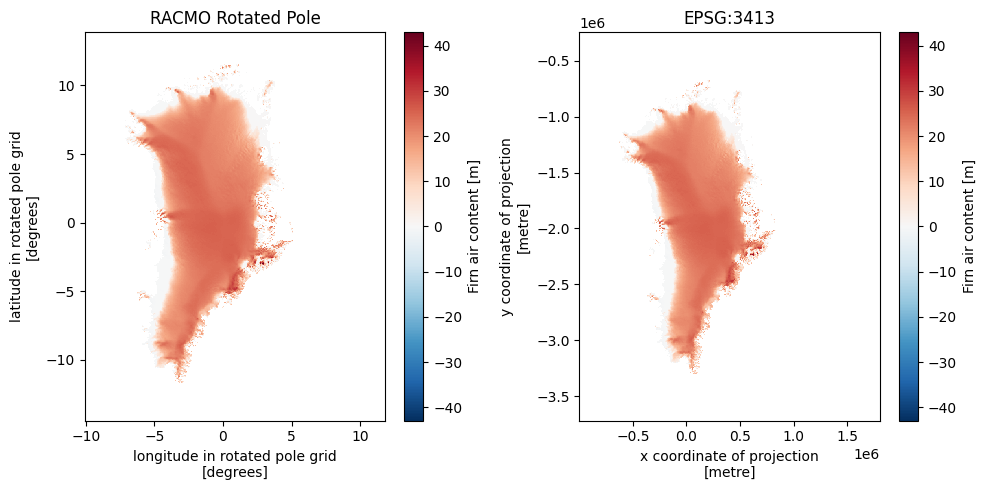

In [27]:


# Select a single timestep (GeoTIFF can't hold a time axis natively)
da = ds[var].isel(time=0)

# Assign dimensions and CRS so rioxarray can do the transform
da = da.rio.set_spatial_dims(x_dim="rlon",y_dim="rlat")
rotpole_proj4 = re.sub(r'-m\s+\S+\s*', '', ds['rotated_pole'].attrs['proj4_params']).strip()
da = da.rio.write_crs(rotpole_proj4)

# Reproject to target CRS
da_reproj = da.rio.reproject(target_crs)

fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(10,5))
ds.FirnAir.isel(time=0).plot(ax=axs[0])
axs[0].set_title("RACMO Rotated Pole")
da_reproj.plot(ax=axs[1])
axs[1].set_title(target_crs)
plt.tight_layout()

In [28]:
output_filepath = f"./{var}_t0_{target_crs}"

#Write to netcdf
da_reproj.to_netcdf(path=f"{output_filepath}.nc")

#Write to GeoTIFF
da_reproj.rio.to_raster(f"{output_filepath}.tif")

You might want to write out a multi-band geotiff with many timesteps. Here's how you do that:

In [ ]:
# To do all timesteps

output_filename = f"./FDM_FGRN055_{var}_{start_year}-{end_year}_{target_crs_name}"

da_all = ds[var].rio.set_spatial_dims(x_dim="rlon", y_dim="rlat")
rotpole_proj4 = re.sub(r'-m\s+\S+\s*', '', ds['rotated_pole'].attrs['proj4_params']).strip()
da_all = da_all.rio.write_crs(rotpole_proj4)
da_all = da_all.rio.reproject(target_crs)

#da_all.isel(time=0).plot()

#Write to netcdf
da_all.to_netcdf(path=f"{output_filename}.nc")

#Write to Geotiff
# Warning: this might crash your kernel if you do it for the whole timeseries
# if so try the rasterio option below or the GDAL option
da_all.rio.to_raster(f"{output_filename}.tif")


585
Number of bands = number of expected timesteps?  True


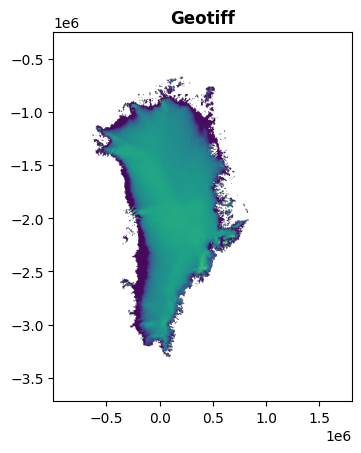

<Axes: title={'center': 'Geotiff'}>

In [ ]:
#Check that the tif saved
tiff = rasterio.open(f"{output_filename}.tif")

print(tiff.count)
eq_ts = (len(ds.time)==tiff.count)
print(f"Number of bands = number of expected timesteps?  {eq_ts}")

fig, ax = plt.subplots(1,2, figsize=(5,10))
rasterio.plot.show(tiff, title = "Geotiff")


In [28]:
# You can also do this with rasterio, which takes less memory
# Reproject a single slice to get output shape/transform/crs

output_filename = f"FDM_FGRN055_rasterio_{var}_{start_year}-{end_year}_{target_crs_name}"

#tell rioxarray which are the spatial coordinates to pay attention to
da_all = ds[var].rio.set_spatial_dims(x_dim="rlon", y_dim="rlat")

#make the source crs explicity
rotpole_proj4 = re.sub(r'-m\s+\S+\s*', '', ds['rotated_pole'].attrs['proj4_params']).strip()
da_all = da_all.rio.write_crs(rotpole_proj4)

#reproject one time to the target_crs - this allows us to keep the memory reasonable for large dataset transforms
t0 = da_all.isel(time=0).rio.reproject(target_crs)

#we can write out the timestamps as tags for each band
times = ds.time.values

profile = {
    'driver':    'GTiff',
    'dtype':     np.float32,
    'crs':       t0.rio.crs,
    'transform': t0.rio.transform(),
    'width':     t0.rio.width,
    'height':    t0.rio.height,
    'count':     len(times),
    'nodata':    np.nan,
    'compress':  'deflate',   # optional: keeps file size manageable
}

with rasterio.open(f"{output_filename}.tif", 'w', **profile) as dst:
    for i, t in enumerate(times):
        band = da_all.isel(time=i).rio.reproject(target_crs)
        dst.write(band.values, i + 1)   # bands are 1-indexed
        dst.update_tags(i+1, time=str(t))



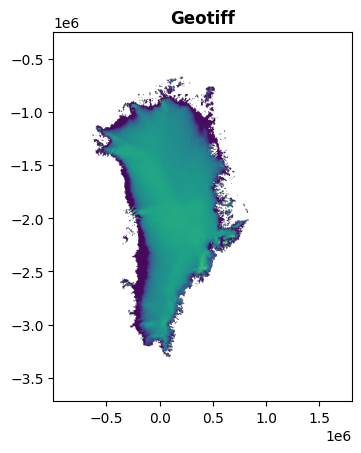

585
2007-01-01 23:59:59 2022-12-28 23:59:59


In [ ]:
# and check output, read back in the times

#Check that the tif saved
tiff = rasterio.open(f"{output_filename}.tif")
rasterio.plot.show(tiff, title = "Geotiff")

with rasterio.open(f"{output_filename}.tif") as src:
    times_read = [src.tags(i)["time"] for i in range(1, src.count + 1)]
    # convert back to datetime if needed
    times_dt = pd.to_datetime(times_read)

print(len(times_dt))
print(times_dt[0],times_dt[-1])

## You can do this all in the commandline using gdal, which can get around memory issues.

To transform in gdal, you need to know some more information. We can get this all from the xarray dataset, and then print out the command you run in gdal in the terminal. In general you need the variable name and the upper left and lower right coordinates

First, we write to a temporary unprojected geotiff

`gdal_translate NETCDF:”filename.nc”:var -a_ullr x_ul_in_rotatedpole y_ul_in_rotatedpole x_lr_in_rotatedpole y_lr_in_rotatedpole  var_temp.tif`

Then we transform it to the projection we're interested in.

`gdalwarp -s_srs "rotated_pole:proj4_params" -t_srs “t_srs" -te xmin ymin xmax ymax -tr xres yres -r interpolation_method var_temp.tif outfile.tif`

In [ ]:
#first write the original, untransformed shortened dataset to an example file
nc_file = f"FDM_FGRN055_{var}_{start_year}-{end_year}.nc"
ds.to_netcdf(f"FDM_FGRN055_{var}_{start_year}-{end_year}.nc")

In [38]:
output_filename = f"FDM_FGRN055_gdal_{var}_{start_year}-{end_year}_{target_crs_name}.tif"

x_ul_in_rotatedpole = min(ds.rlon.values)
y_ul_in_rotatedpole = max(ds.rlat.values)
x_lr_in_rotatedpole = max(ds.rlon.values)
y_lr_in_rotatedpole = min(ds.rlat.values)


# the -m attribute in proj4 params can cause issues. Stripping it out doesn't affect the final product, and often allows the gdalwarp command to actually run
rotpole_raw = ds['rotated_pole'].attrs['proj4_params']
# "-m 57.295779506 +proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5"
rotpole_proj4 = re.sub(r'-m\s+\S+\s*', '', rotpole_raw).strip()
# "+proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5"

#For a 10000x10000 grid
RESX = 10000 
RESY = -10000

x_ul_CRS = -700000
y_ul_CRS = -3500000
x_lr_CRS = 1000000
y_lr_CRS = -500000

run_gdal_translate = f"gdal_translate NETCDF:\"{nc_file}\":{var} -a_ullr {x_ul_in_rotatedpole} {y_ul_in_rotatedpole} {x_lr_in_rotatedpole} {y_lr_in_rotatedpole} tmp_{output_filename}"
print(f"{run_gdal_translate}\n")

run_gdal_warp = f"gdalwarp -s_srs \"{rotpole_proj4}\" -t_srs \"{target_crs}\" -tr {RESX} {RESY} -te {x_ul_CRS} {y_ul_CRS} {x_lr_CRS} {y_lr_CRS} -r near tmp_{output_filename} {output_filename}"
print(f"{run_gdal_warp}")



gdal_translate NETCDF:"FDM_FGRN055_FirnAir_2007-2022.nc":FirnAir -a_ullr -10.050000190734863 13.850000381469727 11.800000190734863 -14.399999618530273 tmp_FDM_FGRN055_gdal_FirnAir_2007-2022_EPSG3413.tif

gdalwarp -s_srs "+proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5" -t_srs "EPSG:3413" -tr 10000 -10000 -te -700000 -3500000 1000000 -500000 -r near tmp_FDM_FGRN055_gdal_FirnAir_2007-2022_EPSG3413.tif FDM_FGRN055_gdal_FirnAir_2007-2022_EPSG3413.tif


Run those two commands in the command line (or using %%bash in a notebook cell here), and then you can plot the geotiff to check using rasterio.

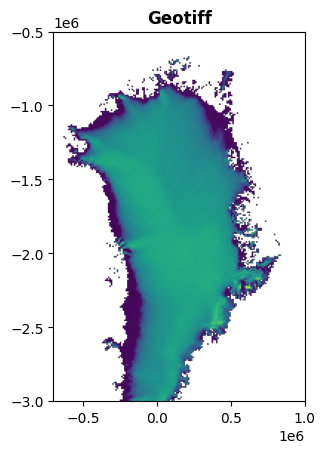

<Axes: title={'center': 'Geotiff'}>

In [ ]:

tiff = rasterio.open(output_filename)
rasterio.plot.show(tiff, title = "Geotiff")

Alternatively, you can do this all in one commandline prompt using gdalwarp

In [39]:
nc_file = f"FDM_FGRN055_{var}_{start_year}-{end_year}.nc"
output_filename = f"FDM_FGRN055_gdal_{var}_{start_year}-{end_year}_{target_crs_name}.tif"

run_gdalwarp = f"gdalwarp -s_srs \"{rotpole_proj4}\" -t_srs \"{target_crs}\" -tr {RESX} {RESY} -te {x_ul_CRS} {y_ul_CRS} {x_lr_CRS} {y_lr_CRS} -r near NETCDF:\"{nc_file}\":{var} {output_filename}"
print(run_gdalwarp)

gdalwarp -s_srs "+proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5" -t_srs "EPSG:3413" -tr 10000 -10000 -te -700000 -3500000 1000000 -500000 -r near NETCDF:"FDM_FGRN055_FirnAir_2007-2022.nc":FirnAir FDM_FGRN055_gdal_FirnAir_2007-2022_EPSG3413.tif


In [ ]:


#first write the original, untransformed shortened dataset to an example file
ds.to_netcdf("example_short_timeseries.nc")

#then specify that path
nc_file = "example_short_timeseries.nc"

#set the output tif path
output_filename = "./FDM_FGRN055_osgeo_gdal_{var}_{start_year}-{end_year}_{target_crs_name}.tif"

# the -m attribute in proj4 params can cause issues. Stripping it out doesn't affect the final product, and often allows the gdalwarp command to actually run
rotpole_raw = ds['rotated_pole'].attrs['proj4_params']
# "-m 57.295779506 +proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5"
rotpole_proj4 = re.sub(r'-m\s+\S+\s*', '', rotpole_raw).strip()
# "+proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5"

print("Source CRS:", rotpole_proj4)

#Transform to desired CRS

ds_out = gdal.Warp(
    output_filename,
    f"NETCDF:{nc_file}:{var}",
    options=gdal.WarpOptions(
        srcSRS=rotpole_proj4,
        dstSRS=target_crs,
        xRes=10000, yRes=10000,
        resampleAlg="bilinear",
        format="GTiff",
        creationOptions=["COMPRESS=DEFLATE", "TILED=YES"],
    )
)
ds_out = None  # flush to disk

Source CRS: +proj=ob_tran +o_proj=latlon +o_lat_p=18.0 +lon_0=-37.5


/usr/local/apps/gdal/3.10.2/lib/python3.12/site-packages/osgeo/gdal.py:314: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


: 

And plot to confirm the ouptut

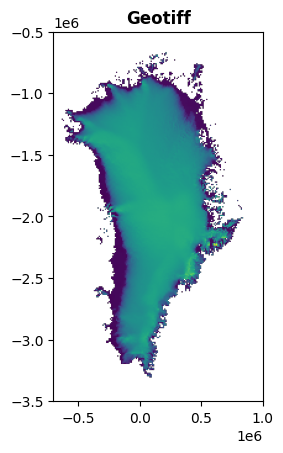

585

In [ ]:
tiff = rasterio.open(output_filename)
rasterio.plot.show(tiff, title = "Geotiff")